# Day 5 - Supervised Learning Mini Project

## Introduction

In this notebook, I will build a complete supervised learning pipeline using the Healthcare Stroke Dataset.

The project includes data exploration, preprocessing, train/test splitting, model training, evaluation, baseline comparison, and model selection.

## Dataset

I used the Healthcare Stroke Dataset.

The target variable is `stroke`:

- 0 = No Stroke
- 1 = Stroke

Since the target contains two classes, this is a classification problem.

In [124]:
## Import Libraries 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier 
from sklearn.dummy import DummyClassifier 
from sklearn.metrics import (
    accuracy_score ,
    precision_score ,
    f1_score,
    confusion_matrix ,
    classification_report 
)
from sklearn.metrics import recall_score
from sklearn.metrics import ConfusionMatrixDisplay

## Hands-On Lab : mini project 
## Step 1 : Choose a provided dataset and determine whether the task is regression or classification.

In [125]:
## Load Datasets 
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


DataSet Information:
I checked the dataset shape ,columns names ,data types , missing values , target distribution

In [126]:
print("shape",df.shape)
print()
print("columns")
print(df.columns)

shape (5110, 12)

columns
Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')


In [127]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [128]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [129]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [130]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


### Observation

The numerical summary shows the mean, minimum, maximum, and quartile values of the numerical features.

The features have different value ranges, so scaling will be useful before training Logistic Regression.

### Observation

The duplicate check shows whether repeated patient records exist in the dataset.

## Target distribution 


In [131]:
df["stroke"].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [132]:
df["stroke"].value_counts(normalize=True) # Calculate the proportion of each class in the stroke column 

stroke
0    0.951272
1    0.048728
Name: proportion, dtype: float64

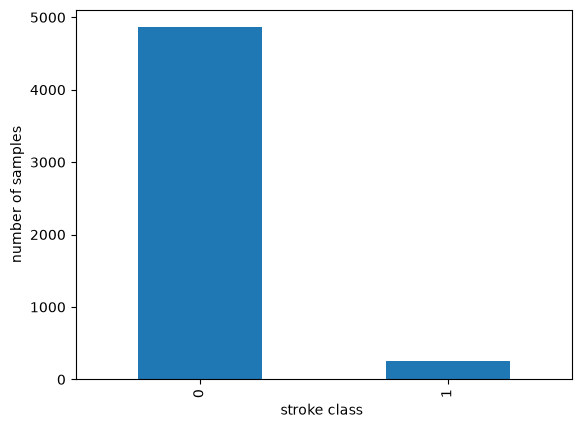

In [133]:
## Target plot 
df["stroke"].value_counts().plot(kind="bar")
plt.xlabel("stroke class ")
plt.ylabel("number of samples")
plt.show()

### observation
The dataset contains numerical values and categorical features 
- the bmi column contains missing values that must be handled before training 
- The target classes are imbalanced because the number of patients without stroke is much larger than the number of patients with stroke 
- for this reason ,accuracy alone may not be enough so recall and f1-score will also be used 


## Step 2: Data Preprocessing

Before training the models, the data needs to be prepared.

The preprocessing steps include:

- Handling missing values.
- Encoding categorical features.
- Splitting the data into training and testing sets.
- Scaling the numerical features.

In [134]:
print("Features shape:", x.shape)
print("Target shape:", y.shape)

Features shape: (5110, 16)
Target shape: (5110,)


### Observation

The `id` column was removed successfully.

The patient features are stored in `x`, while the stroke target is stored in `y`.

### Train/Test Split

The dataset is divided into 80% training data and 20% testing data.

The `stratify` parameter is used to preserve the stroke class distribution in both sets.

In [135]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [136]:
print("x train shape:", x_train.shape)
print("x test shape:", x_test.shape)
print("y train shape:", y_train.shape)
print("y test shape:", y_test.shape)

x train shape: (4088, 16)
x test shape: (1022, 16)
y train shape: (4088,)
y test shape: (1022,)


### observation
the dataset was successfully divided into training and testing sets
And the models will learn from the training set and will be evaluated using unseen test data

### Handle Missing Values

The mean BMI value is calculated using the training data only.

The same training mean is then used to fill the missing BMI values in both sets to avoid data leakage.

In [137]:
x_train = x_train.copy()
x_test = x_test.copy()
bmi_ = x_trian["bmi"].mean()
x_train["bmi"] = x_trian["bmi"].fillna(bmi_)
x_test["bmi"] = x_test["bmi"].fillna(bmi_)


In [138]:
print("training missing values",x_train.isnull().sum().sum())
print("testing missing values",x_test.isnull().sum().sum())

training missing values 0
testing missing values 0


### observation  
all missing bmi values were handled successfuly 
the mean was calculated form the training data only 

### Encode Categorical Features

Categorical columns are converted into numerical dummy variables because machine learning models require numerical input.

In [139]:
x_train_encoded = pd.get_dummies(x_train, drop_first=True)
x_test_encoded = pd.get_dummies(x_test,drop_first=True)

In [140]:

print("Encoded training shape:", x_train_encoded.shape)
print("Encoded testing shape:", x_test_encoded.shape)

Encoded training shape: (4088, 16)
Encoded testing shape: (1022, 16)


### Observation

The categorical features were converted into numerical values using one-hot encoding.

The training and testing sets were aligned to ensure that both contain the same feature columns.

### Feature Scaling

Feature scaling is applied using StandardScaler.

The scaler is fitted only on the training data and then applied to the testing data to avoid data leakage.

In [141]:
scaler = StandardScaler()
x_trian_scaled = scaler.fit_transform(x_train_encoded)
xTest = scaler.transform(x_test_encoded)

In [142]:
print("scaled training shape",x_trian_scaled.shape)
print("scaled testing shape",xTest.shape)

scaled training shape (4088, 16)
scaled testing shape (1022, 16)


## observation 

the featues were standarizef successfully and The scaler was fitted only on the encoded training data and then applied to the encoded testing data, preventing data leakage.

 ## Step 3: Train at least two appropriate models and evaluate them with a suitable metric against a baseline



Three models will be used in this project:

- Dummy Classifier (Baseline)
- Logistic Regression
- Random Forest

The baseline provides a simple reference model, while the other models learn patterns from the training data.

## Baseline Model

The Dummy Classifier always predicts the most frequent class.

Its purpose is to provide a simple baseline for comparison.

In [143]:
base = DummyClassifier(
    strategy="most_frequent"
)
base.fit(x_train_encoded,y_train
)
b_pred = base.predict(x_test_encoded)
print("baseline model trained successfully ")


baseline model trained successfully 


## Logistic Regression

Logistic Regression is a linear classification algorithm.

Because the dataset is imbalanced, `class_weight="balanced"` is used to give more importance to the minority class.

In [144]:
logistic = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic.fit(
    x_train_scaled,
    y_train
)

logistic_pred = logistic.predict(
    xTest
)

print("Logistic Regression trained successfully")
## Balanced class weights help the model pay more attention to stroke cases.

Logistic Regression trained successfully


## Random Forest

Random Forest combines many decision trees to produce more stable predictions.

Unlike Logistic Regression, Random Forest does not require feature scaling.

In [145]:
random_forest = RandomForestClassifier(
    n_estimators=100, # Use 100 decision trees
    class_weight="balanced", # Give more importance to the minority class
    random_state=42 # Ensure reproducible results
)

random_forest.fit(
    x_train_encoded,
    y_train
)
# Predict the stroke classes for the test data
random_forest_pred = random_forest.predict(
    x_test_encoded
)

print("Random Forest trained successfully")



Random Forest trained successfully


##step 3 : Model Evaluation

The three models are evaluated using the same evaluation metrics:

- Accuracy
- Precision
- Recall
- F1-score

Using the same metrics allows a fair comparison between all models.

In [146]:
def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }

In [152]:
def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        )
    }

### Observation

The table compares all models using the same evaluation metrics.

This makes the comparison fair because every model is evaluated using the same test data.

## Model Comparison


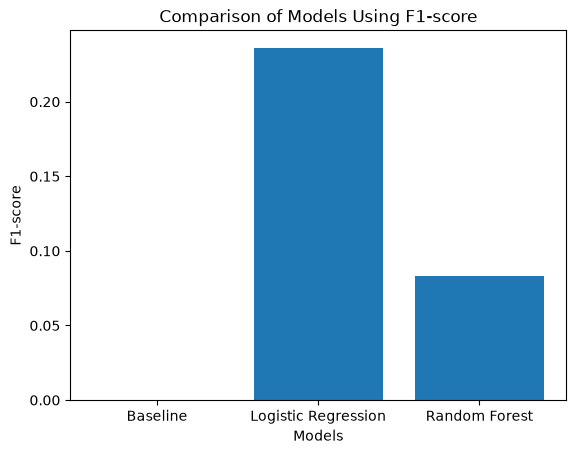

In [148]:
plt.bar(
    comparison_table["Model"],
    comparison_table["F1-score"]
)
plt.xlabel("Models")
plt.ylabel("F1-score")
plt.title("Comparison of Models Using F1-score")

plt.show()

The **Logistic Regression** model achieved the highest F1-score among the evaluated models.

Although all models were compared using the same test data and evaluation metrics, Logistic Regression provided the best balance between precision and recall.

Since the dataset is highly imbalanced, F1-score is a more reliable metric than accuracy alone. Therefore, Logistic Regression was selected as the final model for this project.

In [149]:
## classification report 
print(classification_report(
    y_test,
    logistic_pred,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.99      0.74      0.85       972
           1       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.75      0.82      1022



## Confusion Matrix for Logistic Regression

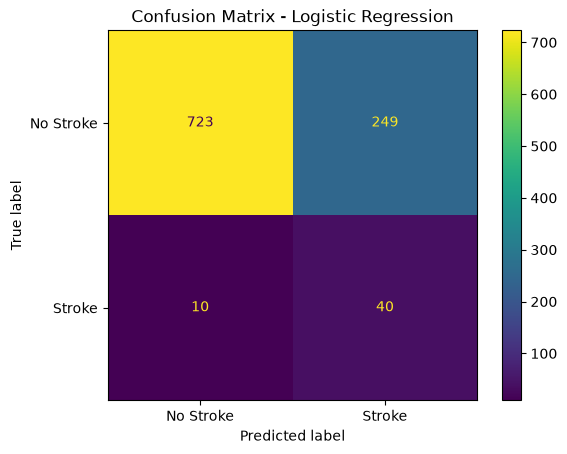

In [150]:
cm = confusion_matrix(
    y_test,
    logistic_pred
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Stroke", "Stroke"]
).plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### Observation

The classification report provides precision, recall, and F1-score for each class.

It gives a more detailed evaluation than a single metric.

### Full Supervised Learning Pipeline

The project followed a complete supervised learning pipeline:

1. Performed a brief exploratory data analysis (EDA).
2. Removed the unnecessary ID column.
3. Split the dataset into training and testing sets.
4. Handled missing BMI values using the training data only.
5. Applied one-hot encoding to categorical features.
6. Standardized the features using StandardScaler.
7. Trained a Dummy Classifier, Logistic Regression, and Random Forest.
8. Evaluated the models using Accuracy, Precision, Recall, and F1-score.
9. Compared the models and selected Logistic Regression as the best-performing model.

### Observation

The complete pipeline ensured that preprocessing was performed correctly without data leakage.

Comparing multiple models made it possible to select the most suitable classifier for this dataset based on objective evaluation metrics.